tpv 模拟数据对细胞做下采样的结果 Velocity Accuracy & 时空开销

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'

sns.set_style("whitegrid", rc={"grid.color": ".9", "axes.edgecolor": ".9",})

In [2]:
base_dir = '/home/nas3/biod/xueweizhi/velocity_benchmark_output/outputs'
data = 'data_simu_samp'
save_dir = f'../figures/{data}'
import os
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [6]:
models = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'velovi', 'topovelo', 'stt', 'velovgi']
metric_name_list = ['velocity_acc', 'time_corr_spearman']
sample_ratio_list = list(np.arange(0.1, 1.0, 0.1))
sample_dir_list = list(range(1, 10, 1))
results = {}
for metric_name in metric_name_list:
    result = []
    if metric_name == 'velocity_acc':
        for model in models:
            for i, sample_ratio in enumerate(sample_ratio_list):
                sample_dir = f'{base_dir}/{data}/{model}/{sample_dir_list[i] if model not in ["unitvelo", "stt", "velovgi"] else f"{sample_ratio:.1f}"}'
                for subdir in os.listdir(sample_dir):
                    metric_path = f'{sample_dir}/{subdir}/metric.csv'
                    if os.path.exists(metric_path):
                        metric_df = pd.read_csv(metric_path, index_col=0)
                        index_name = metric_name if model not in ["unitvelo", "stt", "velovgi"] else f'velocity_acc_{model}_velocity'
                        value = float(metric_df.loc[index_name, '0'])
                        result.append((model if model != 'deepvelo_cui' else 'deepvelo(cui)', sample_ratio, value))
    else:
        for model in models:
            if model == 'stt':
                continue
            for i, sample_ratio in enumerate(sample_ratio_list):
                sample_dir = f'{base_dir}/{data}/{model}/{sample_dir_list[i] if model not in ["unitvelo", "velovgi"] else f"{sample_ratio:.1f}"}'
                for subdir in os.listdir(sample_dir):
                    metric_path = f'{sample_dir}/{subdir}/metric.csv'
                    if os.path.exists(metric_path):
                        metric_df = pd.read_csv(metric_path, index_col=0)
                        if model == 'velovgi':
                            index_name = 'time_corr_spearman_fit_t'
                        elif model == 'unitvelo':
                            index_name = 'time_corr_spearman_pred_t'
                        else:
                            index_name = metric_name
                        value = float(metric_df.loc[index_name, '0'])
                        result.append((model if model != 'deepvelo_cui' else 'deepvelo(cui)', sample_ratio, value))
                        if model == "scvelo":
                            index_name_avg = 'time_corr_spearman_cell_gene'
                            value_avg = float(metric_df.loc[index_name_avg, '0'])
                            result.append(('scvelo(avg)', sample_ratio, value_avg))
    result_df = pd.DataFrame(result, columns=['model', 'ratio', metric_name])
    results[metric_name] = result_df
results

{'velocity_acc':        model  ratio  velocity_acc
 0     scvelo    0.1      0.798116
 1     scvelo    0.1      0.790024
 2     scvelo    0.1      0.790024
 3     scvelo    0.2      0.799935
 4     scvelo    0.2      0.799453
 ..       ...    ...           ...
 214  velovgi    0.8      0.699920
 215  velovgi    0.8      0.711607
 216  velovgi    0.9      0.712568
 217  velovgi    0.9      0.701940
 218  velovgi    0.9      0.711640
 
 [219 rows x 3 columns],
 'time_corr_spearman':            model  ratio  time_corr_spearman
 0         scvelo    0.1           -0.296043
 1    scvelo(avg)    0.1            0.998255
 2         scvelo    0.1           -0.247818
 3    scvelo(avg)    0.1            0.997857
 4         scvelo    0.1           -0.247818
 ..           ...    ...                 ...
 214      velovgi    0.8            0.771798
 215      velovgi    0.8            0.831939
 216      velovgi    0.9            0.855291
 217      velovgi    0.9            0.797607
 218      velovgi   

In [7]:
models_order = ['scvelo', 'scvelo(avg)', 'unitvelo', 'velovae', 'deepvelo(cui)', 'velovi', 'topovelo', 'stt', 'velovgi']

In [8]:
results_sorted = {}
for metric_name, result_df in results.items():
    df = result_df.groupby(['model', 'ratio'])[metric_name].agg(['mean', 'std'])
    df.reset_index(inplace=True)
    df['model'] = pd.Categorical(df['model'], categories=models_order, ordered=True)
    df.sort_values(by=['model', 'ratio'], inplace=True)
    # df.set_index(['model', 'ratio'], inplace=True)
    results_sorted[metric_name] = df
results_sorted

{'velocity_acc':       model  ratio      mean       std
 9    scvelo    0.1  0.792721  0.004672
 10   scvelo    0.2  0.799613  0.000278
 11   scvelo    0.3  0.807024  0.000479
 12   scvelo    0.4  0.812063  0.003241
 13   scvelo    0.5  0.812909  0.002325
 ..      ...    ...       ...       ...
 58  velovgi    0.5  0.688125  0.008153
 59  velovgi    0.6  0.687855  0.005318
 60  velovgi    0.7  0.691277  0.008279
 61  velovgi    0.8  0.703059  0.007489
 62  velovgi    0.9  0.708716  0.005887
 
 [72 rows x 4 columns],
 'time_corr_spearman':       model  ratio      mean       std
 9    scvelo    0.1 -0.263893  0.027843
 10   scvelo    0.2 -0.344303  0.221427
 11   scvelo    0.3 -0.182625  0.089762
 12   scvelo    0.4  0.625805  0.645242
 13   scvelo    0.5  0.658303  0.588947
 ..      ...    ...       ...       ...
 58  velovgi    0.5  0.795316  0.018391
 59  velovgi    0.6  0.790006  0.056722
 60  velovgi    0.7  0.786575  0.052135
 61  velovgi    0.8  0.806451  0.031101
 62  velovgi    

In [45]:
results_sorted['time_corr_spearman']

,model,ratio,mean,std
9,scvelo,0.1,-0.263893,0.027843
10,scvelo,0.2,-0.344303,0.221427
11,scvelo,0.3,-0.182625,0.089762
12,scvelo,0.4,0.625805,0.645242
13,scvelo,0.5,0.658303,0.588947
...,...,...,...,...
58,velovgi,0.5,0.795316,0.018391
59,velovgi,0.6,0.790006,0.056722
60,velovgi,0.7,0.786575,0.052135
61,velovgi,0.8,0.806451,0.031101


In [9]:
colors = {
    'scvelo': plt.cm.Set2(0 / 8),
    'scvelo(avg)': plt.cm.Accent(0 / 8),
    'unitvelo': plt.cm.Set2(1 / 8),
    'velovae': plt.cm.Set2(3 / 8),
    'deepvelo(cui)': plt.cm.Set3(8 / 12),
    'velovi': plt.cm.Set2(2 / 8),
    'topovelo': plt.cm.Set2(6 / 8),
    'stt': plt.cm.Set2(4 / 8),
    'velovgi': plt.cm.tab20c(0 / 20),
}

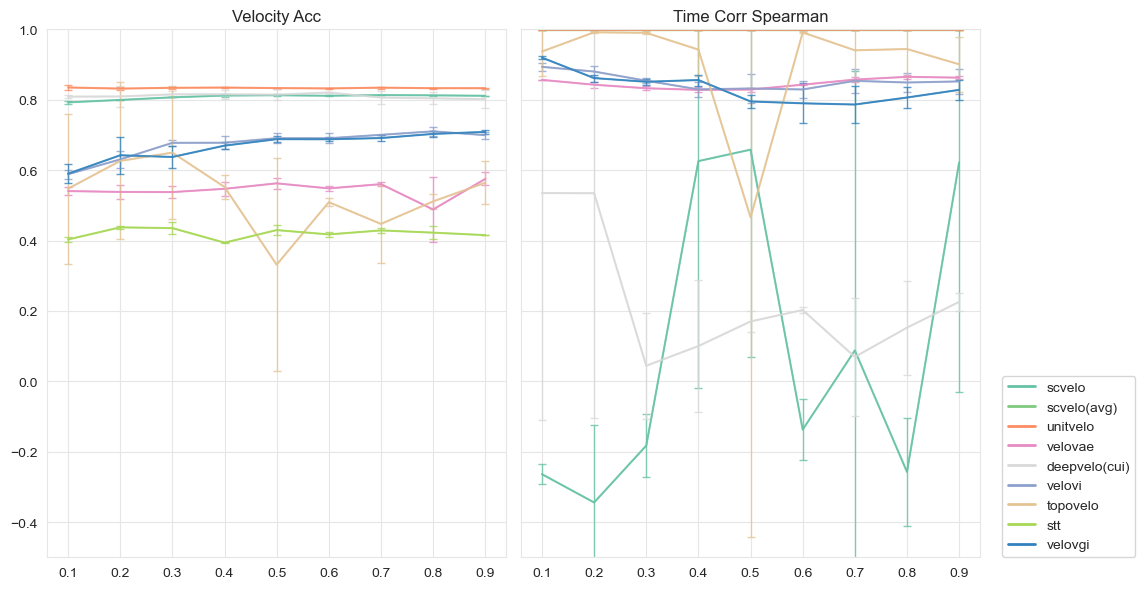

In [10]:
fig, axes = plt.subplots(1, len(results_sorted), sharex=True, sharey=True, figsize=(10, 6))
for i, (metric_name, result_df) in enumerate(results_sorted.items()):
    sns.lineplot(data=result_df, x='ratio', y='mean', hue='model', palette=colors, ax=axes[i], linewidth=1, alpha=0.8, legend=False)
    for model in result_df['model'].unique():
        model_df = result_df[result_df['model'] == model]
        axes[i].errorbar(model_df['ratio'], model_df['mean'], yerr=model_df['std'], fmt='-', color=colors[model], capsize=3, markersize=0, elinewidth=1, alpha=0.8)
    axes[i].set_title(metric_name.replace('_', ' ').title())
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].set_ylim(-0.5, 1)
from matplotlib.lines import Line2D

# 创建图例句柄（legend handles）
legend_elements = [
    Line2D([0], [0], color=colors['scvelo'], lw=2, label='scvelo'),
    Line2D([0], [0], color=colors['scvelo(avg)'], lw=2, label='scvelo(avg)'),
    Line2D([0], [0], color=colors['unitvelo'], lw=2, label='unitvelo'),
    Line2D([0], [0], color=colors['velovae'], lw=2, label='velovae'),
    Line2D([0], [0], color=colors['deepvelo(cui)'], lw=2, label='deepvelo(cui)'),
    Line2D([0], [0], color=colors['velovi'], lw=2, label='velovi'),
    Line2D([0], [0], color=colors['topovelo'], lw=2, label='topovelo'),
    Line2D([0], [0], color=colors['stt'], lw=2, label='stt'),
    Line2D([0], [0], color=colors['velovgi'], lw=2, label='velovgi'),
]
# 假设你想设置 ratio 的刻度为 0.1 到 0.9
xticks = [0.1 * i for i in range(1, 10)]

for ax in axes:
    ax.set_xticks(xticks)  # 设置位置
    ax.set_xticklabels([f"{x:.1f}" for x in xticks])  # 可选：设置格式化标签
# 添加图例到整张图上方（或你可以放到其他位置）
fig.legend(handles=legend_elements, loc='lower left', bbox_to_anchor=(1, 0.05))
plt.tight_layout()
plt.savefig(f'{save_dir}/{"_".join(results_sorted.keys())}.svg.svg', bbox_inches='tight')
plt.show()
    

In [36]:
models = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'velovi', 'topovelo', 'stt', 'velovgi']
metric_name_list = ['train_time', 'cpu_mem_usage', 'gpu_mem_usage']
sample_ratio_list = list(np.arange(0.1, 1.0, 0.1))
sample_dir_list = list(range(1, 10, 1))
results = {}
for metric_name in metric_name_list:
    result = []
    for model in models:
        if metric_name == 'gpu_mem_usage' and model in ['scvelo', 'stt']:
            continue
        for i, sample_ratio in enumerate(sample_ratio_list):
            sample_dir = f'{base_dir}/{data}/{model}/{sample_dir_list[i] if model not in ["unitvelo", "stt", "velovgi"] else f"{sample_ratio:.1f}"}'
            for subdir in os.listdir(sample_dir):
                metric_path = f'{sample_dir}/{subdir}/metric.csv'
                if os.path.exists(metric_path):
                    metric_df = pd.read_csv(metric_path, index_col=0)
                    index_name = 'mem_usage' if metric_name == 'cpu_mem_usage' and model not in ["unitvelo", "stt", "velovgi"] else metric_name
                    value = float(metric_df.loc[index_name, '0'])
                    result.append((model if model != 'deepvelo_cui' else 'deepvelo(cui)', sample_ratio, value))
    result_df = pd.DataFrame(result, columns=['model', 'ratio', metric_name])
    results[metric_name] = result_df

results_sorted = {}
for metric_name, result_df in results.items():
    df = result_df.groupby(['model', 'ratio'])[metric_name].agg(['mean', 'std'])
    df.reset_index(inplace=True)
    df['model'] = pd.Categorical(df['model'], categories=models_order, ordered=True)
    df.sort_values(by=['model', 'ratio'], inplace=True)
    # df.set_index(['model', 'ratio'], inplace=True)
    results_sorted[metric_name] = df
results_sorted

{'train_time':       model  ratio         mean         std
 9    scvelo    0.1   282.302948   76.984678
 10   scvelo    0.2   536.345327  162.379294
 11   scvelo    0.3   778.085218  206.961580
 12   scvelo    0.4  1075.646362  336.587322
 13   scvelo    0.5  1503.900085  573.051492
 ..      ...    ...          ...         ...
 58  velovgi    0.5   169.855268   15.090642
 59  velovgi    0.6   196.114602   21.240733
 60  velovgi    0.7   177.216404    5.232703
 61  velovgi    0.8   202.816242   16.688398
 62  velovgi    0.9   347.997761   74.574888
 
 [72 rows x 4 columns],
 'cpu_mem_usage':       model  ratio         mean         std
 9    scvelo    0.1  1365.953125  267.730779
 10   scvelo    0.2  1691.002604  209.866121
 11   scvelo    0.3  1936.303385  261.450828
 12   scvelo    0.4  2257.657552  213.205785
 13   scvelo    0.5  2527.872396  244.576950
 ..      ...    ...          ...         ...
 58  velovgi    0.5  3822.848958   14.962286
 59  velovgi    0.6  3885.257812    6.34496

In [37]:
results_final = {}
train_time = results_sorted['train_time']
results_final['CPU Memory Usage'] = results_sorted['cpu_mem_usage']
results_final['GPU Memory Usage'] = results_sorted['gpu_mem_usage']
results_final['Train Time (scvelo, stt)'] = train_time[train_time['model'].isin(['scvelo', 'stt'])]
results_final['Train Time (velovae, topovelo)'] = train_time[train_time['model'].isin(['velovae', 'topovelo'])]
results_final['Train Time (deepvelo)'] = train_time[train_time['model'] == 'deepvelo(cui)']
results_final['Train Time (unitvelo, velovi, velovgi)'] = train_time[train_time['model'].isin(['unitvelo', 'velovi', 'velovgi'])]
results_final

{'CPU Memory Usage':       model  ratio         mean         std
 9    scvelo    0.1  1365.953125  267.730779
 10   scvelo    0.2  1691.002604  209.866121
 11   scvelo    0.3  1936.303385  261.450828
 12   scvelo    0.4  2257.657552  213.205785
 13   scvelo    0.5  2527.872396  244.576950
 ..      ...    ...          ...         ...
 58  velovgi    0.5  3822.848958   14.962286
 59  velovgi    0.6  3885.257812    6.344962
 60  velovgi    0.7  3947.446615    8.491768
 61  velovgi    0.8  4036.670573   12.466414
 62  velovgi    0.9  4185.218750   16.513254
 
 [72 rows x 4 columns],
 'GPU Memory Usage':             model  ratio         mean        std
 18       unitvelo    0.1   818.000000   0.000000
 19       unitvelo    0.2   830.000000   0.000000
 20       unitvelo    0.3  1350.000000   0.000000
 21       unitvelo    0.4  1334.000000   0.000000
 22       unitvelo    0.5  2390.000000   0.000000
 23       unitvelo    0.6  2390.000000   0.000000
 24       unitvelo    0.7  2358.000000   0.0

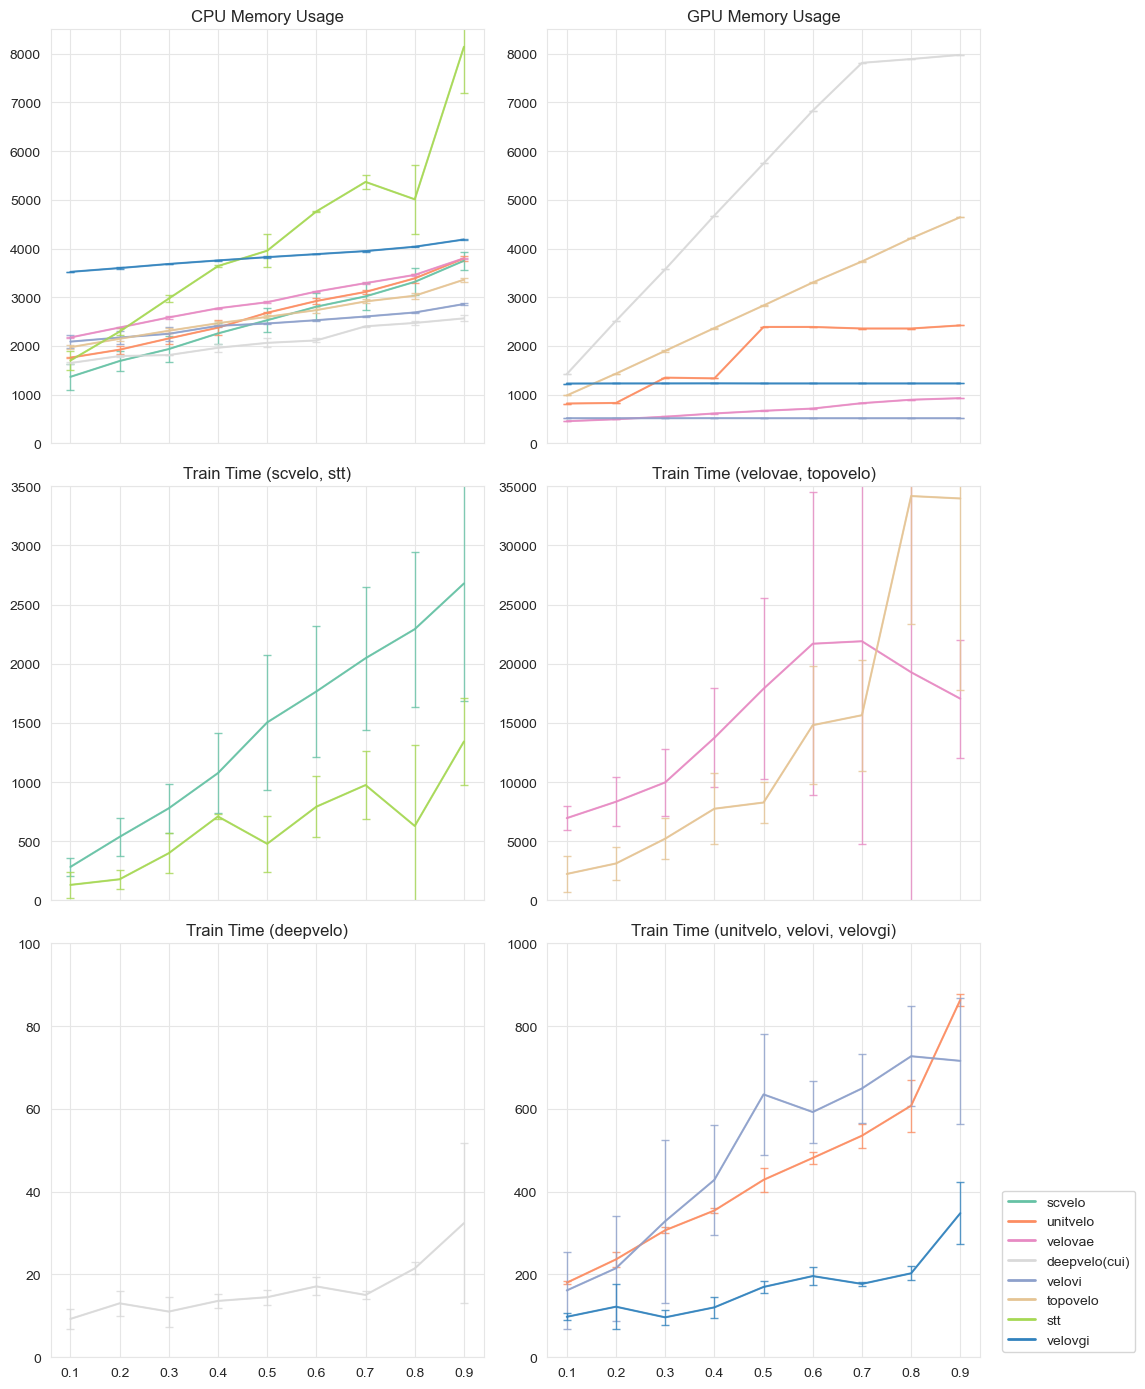

In [43]:
fig, axes = plt.subplots(3, 2, sharex=True, sharey=False, figsize=(10, 14))
xticks = [0.1 * i for i in range(1, 10)]
ylims = [(0, 8500), (0, 8500), (0, 3500), (0, 35000), (0, 100), (0, 1000)]
for i, (metric_name, result_df) in enumerate(results_final.items()):
    ax = axes[i // 2, i % 2]
    sns.lineplot(data=result_df, x='ratio', y='mean', hue='model', palette=colors, ax=ax, linewidth=1, alpha=0.8, legend=False)
    for model in result_df['model'].unique():
        model_df = result_df[result_df['model'] == model]
        ax.errorbar(model_df['ratio'], model_df['mean'], yerr=model_df['std'], fmt='-', color=colors[model], capsize=3, markersize=0, elinewidth=1, alpha=0.8)
    ax.set_title(metric_name)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_ylim(ylims[i])
    ax.set_xticks(xticks)  # 设置位置
    ax.set_xticklabels([f"{x:.1f}" for x in xticks])  # 可选：设置格式化标签

from matplotlib.lines import Line2D

# 创建图例句柄（legend handles）
legend_elements = [
    Line2D([0], [0], color=colors['scvelo'], lw=2, label='scvelo'),
    Line2D([0], [0], color=colors['unitvelo'], lw=2, label='unitvelo'),
    Line2D([0], [0], color=colors['velovae'], lw=2, label='velovae'),
    Line2D([0], [0], color=colors['deepvelo(cui)'], lw=2, label='deepvelo(cui)'),
    Line2D([0], [0], color=colors['velovi'], lw=2, label='velovi'),
    Line2D([0], [0], color=colors['topovelo'], lw=2, label='topovelo'),
    Line2D([0], [0], color=colors['stt'], lw=2, label='stt'),
    Line2D([0], [0], color=colors['velovgi'], lw=2, label='velovgi'),
]

fig.legend(handles=legend_elements, loc='lower left', bbox_to_anchor=(1, 0.025))
plt.tight_layout()
plt.savefig(f'{save_dir}/{"_".join(results_sorted.keys())}.svg.svg', bbox_inches='tight')
plt.show()